In [2]:
#Import some things
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import astropy.coordinates as coord
import astropy.units as u
from astropy.io import fits
from astropy.table import Table,join
from astropy.coordinates import SkyCoord
from astropy.io import ascii as asciitable
from unique import unique

In [5]:
data=Table.read('MeridithRomanApokascCalibtest1005.out', format='ascii')

In [6]:
data

KICID,gaiaM,logg-Spec,feh,alphafe,Teff,EvolState,Mass,logg-Seis,Lgaia,InvRGaia,CatTab,TMASSID,IntTeff,IntML,IntAge,IntC12,IntC13,IntN14,IntXsurf
int64,float64,float64,float64,float64,float64,str7,float64,float64,float64,float64,str8,str17,float64,float64,float64,float64,float64,float64,float64
893214,1.534781561666196,2.4559,-0.2617,0.0815,4718.9233,RGB,1.4404,2.5146,65.58790223050943,0.082389,Gold,J19245967+3638183,4612.6,1.895777,2.2189,0.0011604,4.6208e-05,0.001106,0.70721
1026180,1.269251408771202,2.4066,0.2741,0.0215,4576.1016,RC,1.5334,2.4512,53.73234326297827,0.085599,Gold,J19241923+3645378,4317.6,2.206439,5.9367,0.0041941,0.00015165,0.0029808,0.65341
1026309,2.7493790805550327,2.2388,0.1609,-0.0295,4479.2246,RGB,2.642,2.1176,157.23581496063582,0.047943,Silver,J19242636+3643594,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
1026452,1.9573936041099025,2.4907,-0.2652,0.0658,4910.6035,RC,1.4618,2.451,90.536381837271,0.075937,Gold,J19243452+3647244,4694.0,2.077073,0.96599,0.0010514,4.4323e-05,0.0012371,0.71386
1027110,1.264623281628865,1.7495,-0.3017,0.2615,4194.4375,RGB,1.0367,1.6949,171.57799019996384,0.040245,Silver,J19250937+3644599,4163.2,1.779821,4.6342,0.0011448,4.1871e-05,0.00086404,0.69626
1027337,1.4642604148040177,2.7836,0.2081,0.0354,4621.996,RGB,1.2676,2.7732,27.079589486844164,0.123008,Gold,J19252021+3647118,4543.7,1.85323,3.4015,0.0034101,0.00013183,0.0028651,0.66528
1027707,2.83488831898619,1.4062,0.1105,0.0356,3961.365,RGB,2.0033,1.3484,674.5604715171565,0.018104,Silver,J19253846+3646103,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0,-99.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1723843,1.4809530083968647,2.9236,-0.2529,0.0683,4947.5244,RGB,1.4641,2.9622,26.049449549811282,0.143705,Gold,J19280451+3713548,4837.4,1.897931,2.4615,0.001211,4.7558e-05,0.0010978,0.70675


In [20]:
rc=np.where(data['EvolState']=='RC')
rgb=np.where(data['EvolState']=='RGB')
rgbgood=np.where((data['EvolState']=='RGB') &(data['IntTeff']>0))

In [22]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Create sample data (X must be 2D)
X = np.array(data['feh'][rgbgood]).reshape(-1, 1)
y = np.array(data['Teff'][rgbgood]-data['IntTeff'][rgbgood])

# 2. Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# 3. Get results
print(f"Slope: {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

# 4. Make a prediction
prediction = model.predict([[6]])

Slope: 8.40171005105601
Intercept: 122.08646424675823


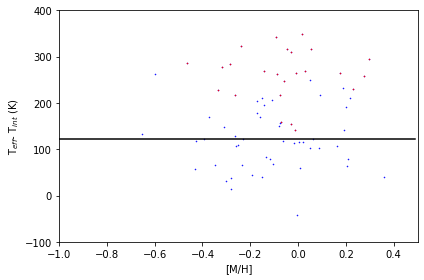

In [24]:
plt.scatter(data['feh'], data['Teff']
            -data['IntTeff'], s=0.3, color='b')
plt.scatter(data['feh'][rc], data['Teff'][rc]
            -data['IntTeff'][rc], s=0.3, color='r')
#plt.scatter(data['APOKASC3_M_H'][clump], data['APOKASC3_TEFF'][clump]
#            -data['APOKASC3_TEFFMOD_JT'][clump], s=0.3, color='r')
plt.xlabel('[M/H]')
plt.ylabel('T$_{eff}$- T$_{int}$ (K)')
#plt.colorbar(label='[M/H]')
#plt.text(-0.9, 300, 'RC', color='r')
#plt.text(-0.9, -50, 'RGB', color='b')
mets=np.arange(-1.5, 0.5, 0.01)
plt.plot(mets, 8.4*mets*0+122.1, 'k-')
#plt.plot(mets, 150*np.sin(mets*360/np.pi/25+0.4)+50, 'k-')
#plt.plot([-1.0, 0.0], [100+140], 'k-')

#plt.plot([-0.6, 0.4], [380,210], 'k-')
#plt.plot([-0.25, 0.4], [100,100], 'k-')
#plt.plot([-0.25, -0.8], [100,30], 'k-')
plt.xlim(-1.0, 0.5)
plt.ylim(-100, 400)
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('teffOffset.jpg', bbox_inches='tight')

In [23]:
y

array([106.3233,  31.2375,  78.296 , 195.688 , 121.477 , 123.0086,
       116.2114,  62.7097, 118.666 , 128.189 , 107.102 , 133.4486,
        82.2946,  39.099 , 150.5866, 102.4637, 112.953 ,  43.4748,
       -41.5404, 231.494 ,  79.142 ,  56.338 , 103.6867,  65.304 ,
        66.229 , 147.0705, 216.733 , 206.6117, 210.7194, 141.2646,
        14.5907, 117.0106, 177.765 , 261.945 ,  59.3976, 156.8967,
       249.1697, 170.444 ,  41.004 ,  68.1425,  38.8543, 204.2013,
       210.7037, 121.3603, 169.0283, 110.1244, 191.7643, 116.1486])

In [28]:
import numpy as np
from sklearn.linear_model import LinearRegression

# 1. Create sample data (X must be 2D)
X = np.array(data['feh'][rgbgood]).reshape(-1, 1)
y = np.array(data['IntML'][rgbgood])

# 2. Initialize and fit the model
model = LinearRegression()
model.fit(X, y)

# 3. Get results
print(f"Slope: {model.coef_[0]}")
print(f"Intercept: {model.intercept_}")

# 4. Make a prediction
prediction = model.predict([[6]])

Slope: 0.01978873258709745
Intercept: 1.9378035092646158


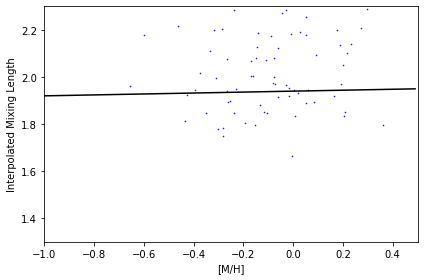

In [30]:
plt.scatter(data['feh'], data['IntML'], s=0.3, color='b')
#plt.scatter(data['APOKASC3_M_H'][clump], data['APOKASC3_TEFF'][clump]
#            -data['APOKASC3_TEFFMOD_JT'][clump], s=0.3, color='r')
plt.xlabel('[M/H]')
plt.ylabel('Interpolated Mixing Length')
#plt.colorbar(label='[M/H]')
#plt.text(-0.9, 300, 'RC', color='r')
#plt.text(-0.9, -50, 'RGB', color='b')
mets=np.arange(-1.5, 0.5, 0.01)

plt.plot(mets, 0.02*mets+1.94, 'k-')
#plt.plot(mets, 0.2*np.sin(mets*12/np.pi+0.1)+1.8, 'k-')
#plt.plot([-1.0, 0.0], [100+140], 'k-')

#plt.plot([-0.6, 0.4], [380,210], 'k-')
#plt.plot([-0.25, 0.4], [100,100], 'k-')
#plt.plot([-0.25, -0.8], [100,30], 'k-')
plt.xlim(-1.0, 0.5)
plt.ylim(1.3, 2.3)
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('InterpolatedML.jpg', bbox_inches='tight', dpi=600)

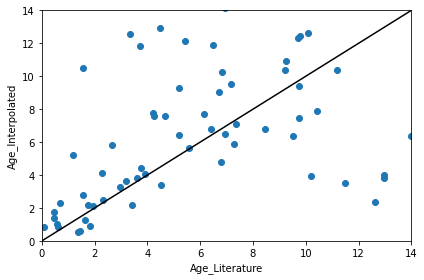

In [13]:
plt.scatter(data['StoneMartinez2025_Age'], data['IntAge'])
plt.xlim(0, 14)
plt.ylim(0, 14)
plt.xlabel('Age_Literature')
plt.ylabel('Age_Interpolated')
plt.plot([0,14], [0,14], 'k-')
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('Agecompare.jpg', bbox_inches='tight', dpi=600)

In [71]:
#cool so if we put these parameters into the models with the right mixing length, do we get the right ages?

In [15]:
dataNS=Table.read('RomanStoneMartinezInterpolatev25ns3.out', format='ascii')

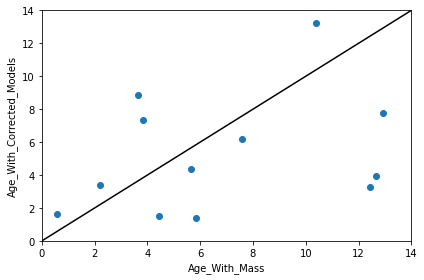

In [16]:
plt.scatter(data['IntAge'], dataNS['IntAge'])
plt.xlim(0, 14)
plt.ylim(0, 14)
plt.xlabel('Age_With_Mass')
plt.ylabel('Age_With_Corrected_Models')
plt.plot([0,14], [0,14], 'k-')
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('AgecompareMyModels.jpg', bbox_inches='tight', dpi=600)

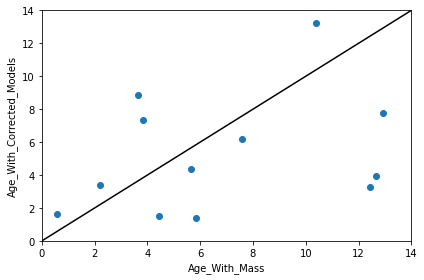

In [17]:
plt.scatter(data['IntAge'], dataNS['IntAge'])
plt.xlim(0, 14)
plt.ylim(0, 14)
plt.xlabel('Age_With_Mass')
plt.ylabel('Age_With_Corrected_Models')
plt.plot([0,14], [0,14], 'k-')
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('AgecompareMyModels.jpg', bbox_inches='tight', dpi=600)

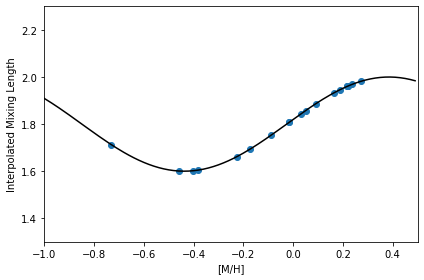

In [19]:
plt.scatter(dataNS['M_H'], dataNS['IntTeff'])
plt.xlim(-1.0, 0.5)
plt.ylim(1.3, 2.3)
mets=np.arange(-1.5, 0.5, 0.01)
plt.plot(mets, 0.2*np.sin(mets*12/np.pi+0.1)+1.8, 'k-')
plt.xlabel('[M/H]')
plt.ylabel('Interpolated Mixing Length')
#plt.plot([0,14], [0,14], 'k-')
plt.tight_layout()        # auto-adjust boundaries after you have added everything
plt.draw()                # make sure it updates (possibly unnecessary)
plt.savefig('SpecMixingLength.jpg', bbox_inches='tight', dpi=600)

In [ ]:
#generate metallicity ranges to make banana

In [81]:
base=Table.read('RomanStoneMartinezInterpolate.txt', format='ascii')

In [82]:
base

sdss_id,StoneMartinez2025_Mass,logg,m_h_atm,alpha_m_atm,teff,c_n,StoneMartinez2025_Age,e_logg,e_m_h_atm,e_alpha_m_atm,e_teff,sdss4_apogee_id
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str18
129042025,0.9438877755511023,1.797383189201355,-0.40165001153945923,0.2390582114458084,4175.41552734375,0.02174001932144165,10.072144288577157,0.04393709450960159,0.014187299646437168,0.01492649968713522,12.193188667297363,2M17503205-3017049
82245639,1.2625250501002,2.8121178150177,0.23800000548362732,-0.03523179516196251,4526.32861328125,-0.26231300830841064,7.266533066132265,0.030825594440102577,0.011500000022351742,0.010999999940395355,10.623588562011719,2M17503456-3013361
82245800,1.3587174348697393,2.2940104007720947,-0.017000000923871994,-0.043231796473264694,4440.98876953125,-0.3999300003051758,3.587587587587588,0.029825594276189804,0.010499999858438969,0.010499999858438969,7.4455885887146,2M17504038-3012058
82245868,1.6472945891783568,2.815610647201538,0.21785999834537506,-0.03861579671502113,4720.28369140625,-0.4141699969768524,3.4054054054054053,0.0338565930724144,0.012185350060462952,0.012179950252175331,20.157989501953125,2M17504533-3010205
129055734,0.9799599198396796,2.518892526626587,-0.7384300231933594,-0.4123218059539795,4779.7080078125,-0.06681191921234131,5.527054108216433,0.0941355973482132,0.02455350011587143,0.03135799989104271,138.70758056640625,AP17495731-3012558
82247040,1.665330661322645,2.851531505584717,0.3091599941253662,-0.030658794566988945,4722.7646484375,-0.5196700096130371,1.7517517517517518,0.03563959524035454,0.012854299508035183,0.012918650172650814,25.283588409423828,2M17504709-3006177
...,...,...,...,...,...,...,...,...,...,...,...,...
125710525,0.9438877755511023,1.6471116542816162,0.3863599896430969,-0.06511979550123215,3599.85888671875,-0.04121202230453491,6.992992992992993,0.03001389466226101,0.010997200384736061,0.010352689772844315,6.793788909912109,2M17455419-2851372
129057611,1.1002004008016029,0.7350779175758362,-0.43553000688552856,0.255338191986084,3591.86181640625,-0.26006001234054565,7.371371371371371,0.032354194670915604,0.011187699623405933,0.011554449796676636,6.597848892211914,2M17445609-2905342


In [83]:
base['m_h_atm']=base['m_h_atm']*0.0-1.0

In [84]:
base

sdss_id,StoneMartinez2025_Mass,logg,m_h_atm,alpha_m_atm,teff,c_n,StoneMartinez2025_Age,e_logg,e_m_h_atm,e_alpha_m_atm,e_teff,sdss4_apogee_id
int64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,float64,str18
129042025,0.9438877755511023,1.797383189201355,-1.0,0.2390582114458084,4175.41552734375,0.02174001932144165,10.072144288577157,0.04393709450960159,0.014187299646437168,0.01492649968713522,12.193188667297363,2M17503205-3017049
82245639,1.2625250501002,2.8121178150177,-1.0,-0.03523179516196251,4526.32861328125,-0.26231300830841064,7.266533066132265,0.030825594440102577,0.011500000022351742,0.010999999940395355,10.623588562011719,2M17503456-3013361
82245800,1.3587174348697393,2.2940104007720947,-1.0,-0.043231796473264694,4440.98876953125,-0.3999300003051758,3.587587587587588,0.029825594276189804,0.010499999858438969,0.010499999858438969,7.4455885887146,2M17504038-3012058
82245868,1.6472945891783568,2.815610647201538,-1.0,-0.03861579671502113,4720.28369140625,-0.4141699969768524,3.4054054054054053,0.0338565930724144,0.012185350060462952,0.012179950252175331,20.157989501953125,2M17504533-3010205
129055734,0.9799599198396796,2.518892526626587,-1.0,-0.4123218059539795,4779.7080078125,-0.06681191921234131,5.527054108216433,0.0941355973482132,0.02455350011587143,0.03135799989104271,138.70758056640625,AP17495731-3012558
82247040,1.665330661322645,2.851531505584717,-1.0,-0.030658794566988945,4722.7646484375,-0.5196700096130371,1.7517517517517518,0.03563959524035454,0.012854299508035183,0.012918650172650814,25.283588409423828,2M17504709-3006177
...,...,...,...,...,...,...,...,...,...,...,...,...
125710525,0.9438877755511023,1.6471116542816162,-1.0,-0.06511979550123215,3599.85888671875,-0.04121202230453491,6.992992992992993,0.03001389466226101,0.010997200384736061,0.010352689772844315,6.793788909912109,2M17455419-2851372
129057611,1.1002004008016029,0.7350779175758362,-1.0,0.255338191986084,3591.86181640625,-0.26006001234054565,7.371371371371371,0.032354194670915604,0.011187699623405933,0.011554449796676636,6.597848892211914,2M17445609-2905342


In [86]:
base.write('RomanSM_'+str(-1.0)+'.txt', format='ascii')

In [91]:
for i in range(15):
    j=i*0.1-1.0
    print(j)
    base['m_h_atm']=base['m_h_atm']*0.0+j
    base.write('RomanSM_'+str(j)+'.txt', format='ascii')

-1.0
-0.9
-0.8
-0.7
-0.6
-0.5
-0.3999999999999999
-0.29999999999999993
-0.19999999999999996
-0.09999999999999998
0.0
0.10000000000000009
0.20000000000000018
0.30000000000000004
0.40000000000000013
